In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [3]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                   111, 112, 113, 114, 115, 116, 117, 118, 119, 120],

    "name": ["Arun", "Priya", "Karthik", "Divya", "Rahul",
             "Sneha", "Vijay", "Anitha", "Surya", "Meena",
             "Ajay", "Keerthi", "Ramesh", "Nisha", "Varun",
             "Pooja", "Hari", "Deepika", "Manoj", "Kavya"],
    "attendance": [85, 90, 75, 60, 95, 80, 70, 88, 92, 65,
                   78, 82, 68, 74, 91, 87, 76, 84, 89, 72],

    "internal_marks": [78, 85, 65, 50, 90, 72, 60, 80, 88, 55,
                       70, 75, 58, 64, 92, 86, 69, 77, 84, 62],

    "backlogs": [0, 0, 2, 4, 0, 1, 3, 0, 0, 5,
                 2, 1, 4, 3, 0, 0, 2, 1, 0, 3],

    "cgpa": [8.2, 8.8, 6.5, 5.2, 9.1, 7.4, 6.0, 8.5, 9.0, 5.0,
             6.8, 7.5, 5.8, 6.2, 9.3, 8.7, 6.9, 7.8, 8.6, 6.1]
}

df = pd.DataFrame(data)
print(df)  

    student_id     name  attendance  internal_marks  backlogs  cgpa
0          101     Arun          85              78         0   8.2
1          102    Priya          90              85         0   8.8
2          103  Karthik          75              65         2   6.5
3          104    Divya          60              50         4   5.2
4          105    Rahul          95              90         0   9.1
5          106    Sneha          80              72         1   7.4
6          107    Vijay          70              60         3   6.0
7          108   Anitha          88              80         0   8.5
8          109    Surya          92              88         0   9.0
9          110    Meena          65              55         5   5.0
10         111     Ajay          78              70         2   6.8
11         112  Keerthi          82              75         1   7.5
12         113   Ramesh          68              58         4   5.8
13         114    Nisha          74             

In [4]:
X = df[["attendance", "internal_marks", "backlogs"]]
y = df["cgpa"]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [7]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(3,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'])

c:\Users\navee\Desktop\Data_Scientist\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=4,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 53.6821 - mae: 7.1618 - val_loss: 65.3650 - val_mae: 7.8524
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 53.3858 - mae: 7.1426 - val_loss: 64.9763 - val_mae: 7.8303
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 53.1261 - mae: 7.1261 - val_loss: 64.6019 - val_mae: 7.8087
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 52.8404 - mae: 7.1076 - val_loss: 64.2393 - val_mae: 7.7875
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 52.5735 - mae: 7.0895 - val_loss: 63.8814 - val_mae: 7.7664
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 52.3095 - mae: 7.0722 - val_loss: 63.5340 - val_mae: 7.7456
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 52.0709 - mae: 7.0554 - val_loss: 63.1757 - val_mae: 7.7240
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 51.8154 - mae: 7.0380 - val_loss: 62.8304 - val_mae: 7.7029
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 51.5528

In [9]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 69.5350 - mae: 8.3280
Test Loss: 69.53498840332031
Test MAE: 8.327961921691895


In [10]:
sample = np.array([[85, 80, 1]])
sample_scaled = scaler.transform(sample)
predicted_cgpa = model.predict(sample_scaled)
print("Predicted CGPA:", predicted_cgpa[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted CGPA: 0.091411896


c:\Users\navee\Desktop\Data_Scientist\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


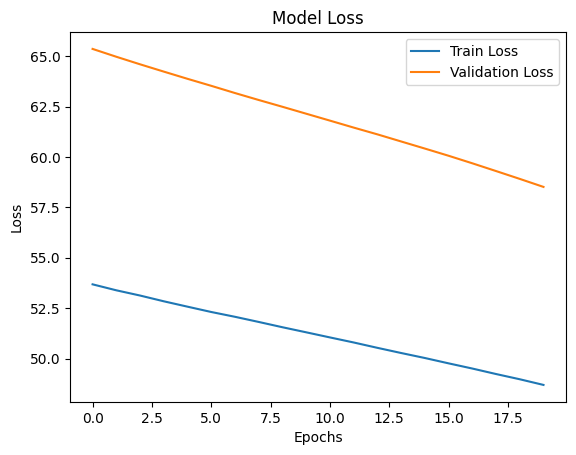

In [11]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
import joblib
joblib.dump(model, 'cgpa_predictor_model.pkl')

['cgpa_predictor_model.pkl']